In [ ]:
# run classical ML model on ref-alt matrix

In [1]:
from sklearn.linear_model import LassoCV, RidgeCV, LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import sys, argparse, os, numpy as np, pandas as pd
from pathlib import Path
from typing import Tuple, Dict


In [2]:
# ────────────────────────────────────────────────────────────
# 0) CONFIGURATION
# ────────────────────────────────────────────────────────────
CONFIG = {
    "FEATURE_DIR" : Path("../data/latest/feature_matrix_labels"),
    "WHO_CATALOG" : Path("../data/filtered_variants_R_only.csv"),
    "SEQ_META"    : Path("../data/catalog/protein_sequences.csv"),
    "PR_OUT_DIR"  : Path("../data/latest/results/interpretability/regression"),
}

DRUG2GENES: Dict[str, list] = {
    # ── single-gene drugs ───────────────────────────────────
    "rifampicin"   : ["rpoB"],
    "pyrazinamide" : ["pncA"],
    "capreomycin"  : ["tlyA"],
    "amikacin"     : ["eis"],
    # ── multi-gene drugs (pre-merged matrices already saved)─
    "moxifloxacin" : ["gyrA", "gyrB"],
    "streptomycin" : ["rpsL", "gid"],
    "isoniazid"    : ["katG", "inhA"],
    "ethionamide"  : ["ethA", "ethR", "inhA"],
    "ethambutol"   : ["embA", "embB", "embC"],
    "levofloxacin" : ["gyrA", "gyrB"],
}

In [3]:
# ────────────────────────────────────────────────────────────
# 1)  COMMON HELPERS
# ────────────────────────────────────────────────────────────


# --- PR Helper Functions ---

def compute_residue_scores(coef: np.ndarray) -> np.ndarray:
    return np.abs(coef)
    
def load_catalog(catalog_path, allowed_confidences):
    catalog = pd.read_csv(catalog_path)
    catalog = catalog[
        (catalog["confidence"].isin(allowed_confidences)) &
        (catalog["intersectional"] == True)
    ].copy()
    catalog["aa_pos_0idx"] = catalog["aa_pos"].astype(int) - 1
 
    return catalog

def evaluate_topk_precision_recall(drug:str, gene_name:str, scores:np.ndarray, catalog_df:pd.DataFrame, k_vals=(10,), model:str="") -> list:
        
    variants_df = catalog_df[catalog_df["gene"].str.lower() == gene_name.lower()].copy()
    if variants_df.empty:
        print(f"Skipping {gene_name}: no intersectional variants found.")
        return []

    total_actual_positives = len(np.unique(variants_df["aa_pos_0idx"]))
    print(f"Total confirmed resistance positions for {gene_name}: {total_actual_positives}")

    imp_df = pd.DataFrame({"Residue_Position": np.arange(len(scores)), "Importance": scores})
    imp_df_sorted = imp_df.sort_values("Importance", ascending=False)
    

    rows = []
    for k in k_vals:
        top_k = imp_df_sorted.head(k)
        # top_k = imp_df.nlargest(int(np.ceil(len(imp_df) * (k / 100))), "Importance")

        important_positions = set(top_k["Residue_Position"])

        true_positions = set(variants_df["aa_pos_0idx"])
        
        true_positives = len(true_positions.intersection(important_positions))
        total_predictions = len(important_positions) #k

        precision = true_positives / total_predictions if total_predictions > 0 else 0
        recall = true_positives / total_actual_positives if total_actual_positives > 0 else 0
        # f1 = 2 * prec * rec / (prec + rec + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        assert precision <= 1.0, f"Precision > 1 for {gene_name} at k={k}"

        matched_df = variants_df[variants_df["aa_pos_0idx"].isin(important_positions)]

        identified_variants = matched_df.drop_duplicates("aa_pos_0idx")["variant"].tolist()
        
        # print(f"Top residues from model {model} for top-k {k}")
        # print(top_k)

        # print("Known resistance positions from WHO (1-indexed):")
        # print(sorted(set(variants_df["aa_pos_0idx"])))


        rows.append({
            "drug": drug, "gene": gene_name, "model": model, "k": k,
            "Total_Resistance_Positions": total_actual_positives,
            "TP": true_positives,
            "precision": precision,
            "recall": recall,
            "F1": f1,
            "identified_variants": ", ".join(identified_variants) if identified_variants else "None"
        })
    return rows



def encode_labels(y):
    le = LabelEncoder()
    return le.fit_transform(y)


def load_feature_matrix_and_labels(drug_name: str):
    """
    Load a design matrix and label vector for *either* a single-gene or
    a pre-merged multi-gene drug.

    • For single-gene drugs it automatically strips the mutation-flag
      column ( column-0 and full of 0/1).
    • For multi-gene drugs it leaves the matrix untouched.
    """
    mat_f = CONFIG["FEATURE_DIR"] / f"{drug_name.upper()}_feature_matrix.npy"
    lab_f = CONFIG["FEATURE_DIR"]/ f"{drug_name.upper()}_labels.npy"

    if not (mat_f.exists() and lab_f.exists()):
        raise FileNotFoundError(
            f"Expected files not found:\n  {mat_f}\n  {lab_f}"
        )

    X = np.load(mat_f)
    y = np.load(lab_f, allow_pickle=True)

    # ── drop mutation flag IFF this is a single-gene drug ──────────
    if len(DRUG2GENES[drug_name]) == 1:
        # extra guard: be sure the first column really *is* a flag
        X = X[:, 1:]
    print(f"{drug_name}: X shape = {X.shape}")
    return X, y

def gene_slices(drug:str, n_cols:int):
    """Return {gene:(start,end)} based on reference lengths."""
    ref = pd.read_csv(CONFIG["SEQ_META"])
    lens={ g:len(ref.loc[ref["gene"]==g,"protein_sequence"].values[0])
           for g in DRUG2GENES[drug]}
    gene_slices,cursor={},0
    for g in DRUG2GENES[drug]:
        L=lens[g]; gene_slices[g]=(cursor,cursor+L); cursor+=L
    assert cursor==n_cols, f"{drug}: expected {cursor}, got {n_cols}"
    return gene_slices

In [4]:
from sklearn.metrics import roc_auc_score, mean_squared_error

def get_scores(model, X, y):
    """Helper: return predictions + safe AUC input."""
    # Try predict_proba
    if hasattr(model, "predict_proba"):
        y_pred = model.predict_proba(X)[:, 1]
    # Fallback: decision_function
    elif hasattr(model, "decision_function"):
        y_pred = model.decision_function(X)
    # Last resort: plain predict (regression or hard labels)
    else:
        y_pred = model.predict(X)
    return y_pred



In [5]:
import numpy as np, shap

def dedup_Xy(X, y):
    Xc = np.ascontiguousarray(X)
    view = Xc.view([('', Xc.dtype)] * Xc.shape[1])
    _, idx = np.unique(view, return_index=True)
    idx = np.sort(idx)
    return Xc[idx], np.asarray(y)[idx], idx

# def disjoint_bg_explain_indices(n, bg_frac=0.10, seed=42, min_bg=1, min_explain=1):
#     range_val = np.random.default_rng(seed)
#     perm = range_val.permutation(n)
#     bg_n = max(min_bg, int(round(bg_frac * n)))
#     bg_n = min(bg_n, n - min_explain)
#     return perm[:bg_n], perm[bg_n:]

import numpy as np
from sklearn.model_selection import train_test_split


def stratified_bg_explain_indices(y, bg_frac=0.10, seed=42, max_bg=None):
    """
    Return disjoint (bg_idx, ex_idx) with BG ~= bg_frac of the pool.
    If both classes exist, BG is stratified so it contains both R/S.
    If only one class exists, it just does a random split.
    Optionally cap BG at max_bg (keeps stratification).
    """
    y = np.asarray(y).astype(int)
    N = len(y)
    idx = np.arange(N)
    
    # 1) get BG/EX with stratification if possible
    if len(np.unique(y)) > 1:
        bg_idx, ex_idx = train_test_split(
            idx, train_size=bg_frac, stratify=y, random_state=seed
        )
    else:
        rng = np.random.default_rng(seed)
        perm = rng.permutation(idx)
        cut = max(1, int(round(bg_frac * N)))
        bg_idx, ex_idx = perm[:cut], perm[cut:]
    # 2) optional cap on BG, keep stratification inside BG
    if max_bg is not None and len(bg_idx) > max_bg:
        bg_idx, _ = train_test_split(
            bg_idx, train_size=max_bg, stratify=y[bg_idx] if len(np.unique(y[bg_idx]))>1 else None,
            random_state=seed
        )
        # recompute EX as the complement (still disjoint
        mask = np.ones(N, dtype=bool)
        mask[bg_idx] = False
        ex_idx = np.where(mask)[0]

    return np.array(bg_idx), np.array(ex_idx)

def split_meta(y, bg_idx, ex_idx, bg_frac, seed, max_bg=None):
    y = np.asarray(y).astype(int)
    N = len(y)
    bg_y, ex_y = y[bg_idx], y[ex_idx]

    meta = {
        "N_total": int(N),
        "bg_frac_req": float(bg_frac),
        "seed": int(seed),
        "max_bg": (None if max_bg is None else int(max_bg)),
        "bg_n": int(len(bg_idx)),
        "ex_n": int(len(ex_idx)),
        "bg_pos": int((bg_y==1).sum()),
        "bg_neg": int((bg_y==0).sum()),
        "ex_pos": int((ex_y==1).sum()),
        "ex_neg": int((ex_y==0).sum()),
        "bg_pos_frac": float((bg_y==1).mean()) if len(bg_y) else 0.0,
        "ex_pos_frac": float((ex_y==1).mean()) if len(ex_y) else 0.0,
        "classes_in_pool": [int(c) for c in np.unique(y).tolist()],
        "classes_in_bg":   [int(c) for c in np.unique(bg_y).tolist()],
        "classes_in_ex":   [int(c) for c in np.unique(ex_y).tolist()],
        "overlap": int(np.intersect1d(bg_idx, ex_idx).size),
        "covers_all": bool(len(np.union1d(bg_idx, ex_idx)) == N),
    }
    return meta

import json, numpy as np, pandas as pd
from pathlib import Path

def save_split_meta(meta, out_dir, stem, bg_idx=None, ex_idx=None):
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)

    # enrich the row a bit
    row = dict(meta)
    row["stem"] = stem
    row["bg_count"] = int(len(bg_idx)) if bg_idx is not None else int(meta.get("actual_bg", 0))
    row["explain_count"] = int(len(ex_idx)) if ex_idx is not None else int(meta.get("actual_explain", 0))

    # write JSON (one-per-run)
    with open(out_dir / f"{stem}_meta.json", "w") as f:
        json.dump(row, f, indent=2)

    # append/update CSV (overwrite same stem if present)
    csv_path = out_dir / "splits_meta.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        if "stem" in df.columns:
            df = df[df["stem"] != stem]  # drop old row for this stem
    else:
        df = pd.DataFrame(columns=["stem"])  # ensure column exists

    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    df.to_csv(csv_path, index=False)




def linear_shap_single_pool(model_fitted, X_full, y_full, bg_frac=0.10, seed=42,
                            max_bg=150, masker_mode="independent"):
    """
    model_fitted: trained sklearn linear model (Lasso/Ridge/LogReg etc.)
    X_full/y_full: concatenate train+test, THEN dedup here for SHAP stage
    masker_mode: "independent" (interventional) or "impute" (correlation-aware)
    """
    X_u, y_u, _ = dedup_Xy(X_full, y_full)
    # bg_idx, ex_idx = disjoint_bg_explain_indices(len(X_u), bg_frac=bg_frac, seed=seed)
    # 2) stratified disjoint BG/EX (PASS y_u, not len(X_u))
    bg_idx, ex_idx = stratified_bg_explain_indices(y_u, bg_frac=bg_frac, seed=seed, max_bg=max_bg)
    uniq_bg = np.unique(y_u[bg_idx])
    print("BG unique labels:", uniq_bg.tolist(), "| count:", uniq_bg.size)
    X_bg, X_explain = X_u[bg_idx], X_u[ex_idx]


    if max_bg is not None:
        bg_idx = bg_idx[:max_bg]

    X_bg, X_explain = X_u[bg_idx], X_u[ex_idx]

    # Choose masker
    # if masker_mode == "impute":
    #     masker = shap.maskers.Impute(X_bg)          # correlation-aware
    # else:
        # masker = shap.maskers.Independent(X_bg)     # interventional (coef * (x - mean) behavior)


    # 3) masker + explainer
    masker = shap.maskers.Impute(X_bg) if masker_mode == "impute" else shap.maskers.Independent(X_bg)
    expl = shap.LinearExplainer(model_fitted, masker)
    phi = expl.shap_values(X_explain)
    # 4) meta (use y_u)
    
    meta = split_meta(y_u, bg_idx, ex_idx, bg_frac=bg_frac, seed=seed, max_bg=max_bg)
    # Quick sanity assertions (optional)
    assert meta["overlap"] == 0
    assert meta["covers_all"]
    # if len(np.unique(y_unique)) > 1:
    #     assert set(meta["classes_in_bg"]) == {0,1}, "BG missing a class!"


    return phi, X_explain, y_u[ex_idx], meta,bg_idx, ex_idx




In [6]:
def greedy_topk_global(rank_df, k, exclude):
    chosen = []
    for pos in rank_df["Residue_Position"]:
        if pos in exclude:
            continue
        chosen.append(pos)
        if len(chosen) == k:
            break
    return chosen

def druglevel_gold_excl(gene_slices, who_df_full, catalog_full):
    """
    Build global (0-based) gold/excluded sets for the whole drug.
    who_df_full should already be filtered to: confidence in {1,2} AND intersectional==True.
    catalog_full is the raw WHO CSV (unfiltered) to detect 'uncertain' or not-intersectional.
    """
    gold, excl = set(), set()
    for g, (start, end) in gene_slices.items():
        rows_bona = who_df_full[who_df_full["gene"].str.lower() == g.lower()]
        rows_all  = catalog_full[catalog_full["gene"].str.lower() == g.lower()]
        gold_local = set(rows_bona["aa_pos_0idx"].astype(int).tolist())
        mask_unc   = rows_all["confidence"].eq("3) Uncertain significance")
        mask_not_i = rows_all["intersectional"] != True
        excl_local = set(rows_all.loc[mask_unc | mask_not_i, "aa_pos_0idx"].astype(int).tolist()) - gold_local
        gold |= {start + p for p in gold_local}
        excl |= {start + p for p in excl_local}
    return gold, excl

def build_hit_variants(top_global_positions, gene_slices, who_df):
    """Return list of variant strings (unique by site) for the global top-k picks."""
    hits = []
    for pos in top_global_positions:
        # find which gene slice pos falls in
        for g, (start, end) in gene_slices.items():
            if start <= pos < end:
                local_pos0 = pos - start
                m = (who_df["gene"].str.lower() == g.lower()) & (who_df["aa_pos_0idx"].astype(int) == local_pos0)
                vs = who_df.loc[m, "variant"].drop_duplicates().tolist()
                if vs:
                    hits.extend(vs)
                break
    # unique, stable order
    seen, uniq = set(), []
    for v in hits:
        if v not in seen:
            seen.add(v); uniq.append(v)
    return uniq


### pytorch version

In [13]:
# import os, math, numpy as np, pandas as pd, torch
# from sklearn.metrics import roc_auc_score
# from sklearn.model_selection import train_test_split
# import matplotlib.pyplot as plt
# from pathlib import Path

# def train_logreg_curve(drug_name, X, y, lr=1e-3, n_epochs=5000, val_frac=0.2,
#                        out_root="../data/latest/results/prediction/logreg"):
#     """
#     Manual logistic regression with Adam optimizer.
#     Logs train/val loss and AUC each epoch for convergence visualization.
#     """
#     os.makedirs(out_root, exist_ok=True)

#     # ───────────── Train/val split ─────────────
#     X_train, X_val, y_train, y_val = train_test_split(
#         X, y, test_size=val_frac, stratify=y, random_state=42
#     )

#     # ───────────── Initialization ─────────────
#     n_features = X_train.shape[1]
#     w = torch.zeros((n_features, 1), dtype=torch.float32, requires_grad=True)
#     b = torch.zeros(1, dtype=torch.float32, requires_grad=True)

#     opt = torch.optim.Adam([w, b], lr=lr)
#     loss_fn = torch.nn.BCEWithLogitsLoss()

#     # convert to tensors
#     X_train_t = torch.tensor(X_train, dtype=torch.float32)
#     y_train_t = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
#     X_val_t   = torch.tensor(X_val, dtype=torch.float32)
#     y_val_t   = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)

#     # smart bias init from class imbalance
#     pR = y_train.mean()
#     with torch.no_grad():
#         b.fill_(math.log(pR / (1 - pR + 1e-8)))

#     hist = []
#     best_val = float("inf")
#     patience, counter = 10, 0

#     for ep in range(1, n_epochs + 1):
#         # ---- Train step ----
#         opt.zero_grad()
#         logits = X_train_t @ w + b
#         loss = loss_fn(logits, y_train_t)
#         loss.backward()
#         opt.step()

#         # ---- Validation ----
#         with torch.no_grad():
#             val_logits = X_val_t @ w + b
#             val_loss = loss_fn(val_logits, y_val_t).item()

#             p_train = torch.sigmoid(logits).cpu().numpy().ravel()
#             p_val   = torch.sigmoid(val_logits).cpu().numpy().ravel()

#             auc_train = roc_auc_score(y_train, p_train)
#             auc_val   = roc_auc_score(y_val, p_val)

#         hist.append({
#             "Epoch": ep,
#             "Train_Loss": float(loss.item()),
#             "Val_Loss": float(val_loss),
#             "Train_AUC": float(auc_train),
#             "Val_AUC": float(auc_val),
#         })

#         # ---- Logging ----
#         if ep % 10 == 0 or ep == 1 or ep == n_epochs:
#             print(f"{drug_name} | Epoch {ep:03d} | "
#                   f"train_loss={loss.item():.4f} | val_loss={val_loss:.4f} | val_auc={auc_val:.3f}")

#         # ---- Early stopping (stable plateau) ----
#         if val_loss < best_val - 1e-5:
#             best_val = val_loss
#             counter = 0
#         else:
#             counter += 1
#             if counter >= patience:
#                 print(f"✓ {drug_name}: early convergence at epoch {ep}")
#                 break

#     # ───────────── Save training history ─────────────
#     hist_df = pd.DataFrame(hist)
#     hist_path = Path(out_root) / f"{drug_name}_training_curve.csv"
#     hist_df.to_csv(hist_path, index=False)

#     # ───────────── Plot curves ─────────────
#     plt.figure(figsize=(6, 4))
#     plt.plot(hist_df["Epoch"], hist_df["Train_Loss"], label="Train Loss")
#     plt.plot(hist_df["Epoch"], hist_df["Val_Loss"], label="Val Loss")
#     plt.xlabel("Epoch"); plt.ylabel("BCE Loss")
#     plt.title(f"Logistic Regression Convergence — {drug_name}")
#     plt.legend(); plt.tight_layout()
#     plt.savefig(Path(out_root) / f"{drug_name}_loss_curve.png", dpi=200)
#     plt.close()

#     plt.figure(figsize=(6, 4))
#     plt.plot(hist_df["Epoch"], hist_df["Val_AUC"], label="Val AUC", color="tab:green")
#     plt.xlabel("Epoch"); plt.ylabel("AUC")
#     plt.title(f"Validation AUC — {drug_name}")
#     plt.legend(); plt.tight_layout()
#     plt.savefig(Path(out_root) / f"{drug_name}_auc_curve.png", dpi=200)
#     plt.close()

#     print(f"📉 Saved training curve for {drug_name} → {hist_path}")
#     return hist_df, w.detach().numpy(), b.detach().numpy()
# # --- Main Training + Evaluation ---
# def run_models(drug_name, k_vals=(10,)):
#     print(f"\n=== Running models for {drug_name} ===")
#     genes = DRUG2GENES[drug_name]
#     X, y = load_feature_matrix_and_labels(drug_name)
#     y_encoded = encode_labels(y)

#     # --- Split for evaluation and SHAP ---
#     X_train, X_test, y_train, y_test = train_test_split(
#         X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
#     )
#     X_full = np.vstack([X_train, X_test])
#     y_full = np.concatenate([y_train, y_test])

#     # --- Load WHO catalogue ---
#     ALLOWED_CONFIDENCES = ["1) Assoc w R", "2) Assoc w R - Interim"]
#     who_df = load_catalog("../data/filtered_variants_output.csv", ALLOWED_CONFIDENCES)
#     catalog_full = pd.read_csv("../data/filtered_variants_output.csv")
#     catalog_full["aa_pos_0idx"] = catalog_full["aa_pos"].astype(int) - 1

#     gene_lengths = gene_slices(drug_name, X.shape[1])
#     results, pr_all_models = {}, []

#     # === Logistic Regression (PyTorch) ==================================
#     print(f"→ Training PyTorch logistic regression for {drug_name}")
#     hist_df, w, b = train_logreg_curve(
#         drug_name, X, y_encoded, lr=1e-3, n_epochs=200, val_frac=0.2
#     )

#     # --- Record metrics ---
#     results["logreg"] = {
#         "Final_Val_AUC": hist_df["Val_AUC"].iloc[-1],
#         "Final_Val_Loss": hist_df["Val_Loss"].iloc[-1],
#         "Final_Train_Loss": hist_df["Train_Loss"].iloc[-1],
#         "Epochs": len(hist_df),
#     }

#     # === Rebuild sklearn model for SHAP =================================
#     from sklearn.linear_model import LogisticRegression
#     sk_model = LogisticRegression()
#     sk_model.coef_ = w.T
#     sk_model.intercept_ = b
#     sk_model.classes_ = np.array([0, 1])

#     # === SHAP-based interpretability ====================================
#     masker_mode = "independent"
#     shap_tag = f"logreg_shap_{masker_mode}"

#     phi, X_ex, y_ex, meta, bg_idx, ex_idx = linear_shap_single_pool(
#         sk_model, X_full, y_full, bg_frac=0.10, seed=42, max_bg=160, masker_mode=masker_mode
#     )
#     save_split_meta(
#         meta,
#         out_dir="../data/latest/results/interpretability/regression/splits",
#         stem=f"{drug_name}_{shap_tag}",
#         bg_idx=bg_idx,
#         ex_idx=ex_idx,
#     )

#     # Global feature importances
#     scores_global = np.abs(phi).max(axis=0)
#     rank_df = (
#         pd.DataFrame({
#             "Residue_Position": np.arange(scores_global.shape[0]),
#             "MaxAbsSHAP": scores_global,
#         })
#         .sort_values("MaxAbsSHAP", ascending=False)
#         .reset_index(drop=True)
#     )

#     gold_global, excl_global = druglevel_gold_excl(gene_lengths, who_df, catalog_full)
#     n_true = len(gold_global)
#     shap_dir = "../data/latest/results/interpretability/regression/shap"
#     os.makedirs(shap_dir, exist_ok=True)
#     rank_df.to_csv(f"{shap_dir}/{drug_name}_{shap_tag}_ranked_SHAP_DRUG.csv", index=False)

#     # Precision–recall evaluation
#     for k in k_vals:
#         topk_global = greedy_topk_global(rank_df, k, exclude=excl_global)
#         k_eff = len(topk_global)
#         tp = len(gold_global & set(topk_global))
#         prec = tp / k_eff if k_eff else 0.0
#         rec = tp / n_true if n_true else 0.0
#         f1 = 2 * prec * rec / (prec + rec + 1e-8) if (prec + rec) else 0.0
#         hit_vars = build_hit_variants(topk_global, gene_lengths, who_df) or ["None"]

#         pr_all_models.append({
#             "drug": drug_name,
#             "gene": "ALL",
#             "model": shap_tag,
#             "k": k,
#             "Total_Resistance_Positions": n_true,
#             "TP": tp,
#             "precision": prec,
#             "recall": rec,
#             "F1": f1,
#             "identified_variants": ", ".join(hit_vars),
#         })

#     # === Print and save outputs =========================================
#     print(f"\n[{drug_name.upper()}] Final Val AUC={results['logreg']['Final_Val_AUC']:.3f} | "
#           f"Val Loss={results['logreg']['Final_Val_Loss']:.4f}")

#     pr_df = pd.DataFrame(pr_all_models)
#     pr_out = f"../data/latest/results/interpretability/regression/pr_tables/PR_{drug_name}.csv"
#     os.makedirs(os.path.dirname(pr_out), exist_ok=True)
#     pr_df.to_csv(pr_out, index=False)

#     return results, pr_df


In [ ]:
import os, json
drug_list = [
    "rifampicin", "pyrazinamide", "capreomycin", "amikacin",
    "isoniazid", "ethionamide", "streptomycin", "ethambutol",
    "moxifloxacin", "levofloxacin"
]


DRUG2GENES = {
    "rifampicin"  : ["rpoB"],
    "pyrazinamide": ["pncA"],
    "capreomycin" : ["tlyA"],
    "amikacin"    : ["eis"],

    "moxifloxacin": ["gyrA","gyrB"],
    "levofloxacin": ["gyrA","gyrB"],
    "isoniazid"   : ["katG","inhA"],
    "streptomycin": ["rpsL","gid"],
    "ethambutol"  : ["embC","embA","embB"],
    "ethionamide" : ["ethA","ethR","inhA"],
}


kvals = (1, 5, 10)
all_results, all_pr = {}, {}

# make results directory if not exist
os.makedirs("../data/latest/results/prediction/logreg", exist_ok=True)

for drug in drug_list:
    if drug not in DRUG2GENES:
        print(f"[skip] {drug}: not in DRUG2GENES mapping.")
        continue

    print("\n" + "=" * 70)
    print(f"  Running models for {drug}")
    print("=" * 70)

    try:
        results, pr_df = run_models(drug, kvals)
        all_results[drug] = results
        all_pr[drug] = pr_df.to_dict(orient="records")

        # save partial JSON after each drug to avoid loss on interruption
        with open("../data/latest/results/prediction/logreg/all_results_tmp.json", "w") as f:
            json.dump(all_results, f, indent=2)
        print(f" Completed {drug}")

    except Exception as e:
        print(f" Error while running {drug}: {e}")


In [ ]:
import os
import pandas as pd
import numpy as np
from glob import glob

LOGREG_DIR = "../data/latest/results/prediction/logreg"
os.makedirs(LOGREG_DIR, exist_ok=True)

summary_records = []

csv_files = sorted(glob(os.path.join(LOGREG_DIR, "*_training_curve.csv")))
print(f" Found {len(csv_files)} training curve files\n")

for fpath in csv_files:
    drug = os.path.basename(fpath).replace("_training_curve.csv", "")
    try:
        df = pd.read_csv(fpath)
        n_epochs = len(df)
        final_val_loss = df["Val_Loss"].iloc[-1]
        final_val_auc = df["Val_AUC"].iloc[-1]

        # convergence detection: small loss change in last 5 epochs
        if n_epochs >= 5:
            tail = df["Val_Loss"].tail(5)
            conv = (max(tail) - min(tail)) < 1e-4
        else:
            conv = False

        summary_records.append({
            "Drug": drug,
            "Epochs": n_epochs,
            "Final_Val_Loss": final_val_loss,
            "Final_Val_AUC": final_val_auc,
            "Converged": conv
        })
    except Exception as e:
        print(f" Error reading {fpath}: {e}")

summary_df = pd.DataFrame(summary_records)
summary_path = os.path.join(LOGREG_DIR, "convergence_summary.csv")
summary_df.to_csv(summary_path, index=False)

print(f" Saved convergence summary → {summary_path}")
print(summary_df)


### scikitlearn 

In [7]:
import matplotlib.pyplot as plt
import numpy as np

## convergence for the scikitlearn CV version

def plot_logreg_convergence(model, drug_name, out_dir="../data/latest/results/prediction/regression/convergence"):
    """Plot and save LogisticRegressionCV convergence diagnostics (auto-scaled)."""
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd, os
    from pathlib import Path

    n_iter = np.array(model.n_iter_).flatten()
    max_iter = model.max_iter
    converged = (n_iter < max_iter).all()
    n_max = n_iter.max()
    n_mean = n_iter.mean()

    os.makedirs(out_dir, exist_ok=True)
    summary_path = Path(out_dir) / "logreg_convergence_summary.csv"

    # Plot
    plt.figure(figsize=(6, 4))
    colors = ["tab:green" if i < max_iter else "tab:red" for i in n_iter]
    plt.bar(range(len(n_iter)), n_iter, color=colors)
    plt.axhline(max_iter, color="gray", linestyle="--", label=f"max_iter={max_iter}")
    plt.title(f"LogReg Convergence per Fold ({drug_name})")
    plt.xlabel("Fold")
    plt.ylabel("Iterations")
    plt.ylim(0, n_max * 1.1)         
    plt.text(len(n_iter)//2, n_max*1.02, f"mean={n_mean:.1f}", ha="center", fontsize=9, color="gray")
    plt.legend()
    plt.tight_layout()
    plt.savefig(Path(out_dir) / f"{drug_name}_convergence_zoomed.png", dpi=200)
    plt.close()

    # Append summary CSV
    row = pd.DataFrame([{
        "Drug": drug_name,
        "MaxIter": max_iter,
        "n_iter_per_fold": list(n_iter),
        "n_iter_mean": float(n_mean),
        "n_iter_max": int(n_max),
        "Converged": converged
    }])
    if summary_path.exists():
        prev = pd.read_csv(summary_path)
        pd.concat([prev, row], ignore_index=True).to_csv(summary_path, index=False)
    else:
        row.to_csv(summary_path, index=False)

    print(f"Zoomed convergence plot saved: {out_dir}/{drug_name}_convergence_zoomed.png")
    print(f" Summary updated: {summary_path}")



In [8]:
# --- Main Training + Evaluation ---
def run_models(drug_name,k_vals=(10,)):
    print(f"\n=== Running models for {drug_name} ===")
    genes = DRUG2GENES[drug]
    X, y = load_feature_matrix_and_labels(drug_name)
    y_encoded = encode_labels(y)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
    )
    # full pool (train ∪ test) for SHAP
    X_full = np.vstack([X_train, X_test])
    y_full = np.concatenate([y_train, y_test])

    ALLOWED_CONFIDENCES = ['1) Assoc w R', '2) Assoc w R - Interim']
    who_df = load_catalog("../data/filtered_variants_output.csv", ALLOWED_CONFIDENCES)
    catalog_full = pd.read_csv("../data/filtered_variants_output.csv")
    catalog_full["aa_pos_0idx"] = catalog_full["aa_pos"].astype(int) - 1

    gene_lengths=gene_slices(drug, X.shape[1])
        


    results = {}
    pr_all_models = []

    def model_runner(name, drug_name, model, coef_extractor):
        model.fit(X_train, y_train)
    
        # --- Train predictions ---
        y_pred_train = get_scores(model, X_train, y_train)
        # --- Test predictions ---
        y_pred_test  = get_scores(model, X_test, y_test)
    
        results[name] = {
            # Test metrics
            'test_r2': model.score(X_test, y_test),
            'test_auc': roc_auc_score(y_test, y_pred_test),
            'test_mse': mean_squared_error(y_test, y_pred_test),
    
            # Train metrics
            'train_r2': model.score(X_train, y_train),
            'train_auc': roc_auc_score(y_train, y_pred_train),
            'train_mse': mean_squared_error(y_train, y_pred_train),
        }


        # === NEW: SHAP-based importance on the same trained model ===
        masker_mode='independent'
        shap_tag = f"{name}_shap_{masker_mode}"
    
        phi, X_ex, y_ex, meta, bg_idx, ex_idx = linear_shap_single_pool(
            model, X_full, y_full, bg_frac=0.10, seed=42, max_bg=160, masker_mode="independent"
        )
        save_split_meta(
            meta,
            out_dir="../data/latest/results/interpretability/regression/splits",
            stem=f"{drug_name}_{name}_{masker_mode}",
            bg_idx=bg_idx, ex_idx=ex_idx
        )
    
        # ---- (B) DRUG-LEVEL ranking & PR (combined across genes) -------
        # global per-feature importance across the whole concatenated input
        scores_global = np.abs(phi).max(axis=0)  # shape: (total_features,)
        rank_df = (pd.DataFrame({
                    "Residue_Position": np.arange(scores_global.shape[0]),
                    "MaxAbsSHAP": scores_global
                 })
                 .sort_values("MaxAbsSHAP", ascending=False)
                 .reset_index(drop=True))
    
        # gold/excluded global sets
        gold_global, excl_global = druglevel_gold_excl(gene_lengths, who_df, catalog_full)
        n_true = len(gold_global)
    
        # save a combined ranked file for the drug/model
        out_dir = "../data/latest/results/interpretability/regression/shap"
        os.makedirs(out_dir, exist_ok=True)
        rank_df.to_csv(
            f"{out_dir}/{drug_name}_{shap_tag}_ranked_SHAP_DRUG.csv",
            index=False
        )
    
        for k in k_vals:
            topk_global = greedy_topk_global(rank_df, k, exclude=excl_global)
            k_eff       = len(topk_global)
            tp          = len(gold_global & set(topk_global))
            prec        = tp / k_eff if k_eff else 0.0
            rec         = tp / n_true if n_true else 0.0
            f1          = 2*prec*rec/(prec+rec+1e-8) if (prec+rec) else 0.0
    
            hit_vars = build_hit_variants(topk_global, gene_lengths, who_df) or ["None"]
    
            pr_all_models.append({
                "drug": drug_name, "gene": "ALL", "model": shap_tag, "k": k,
                "Total_Resistance_Positions": n_true, "TP": tp,
                "precision": prec, "recall": rec, "F1": f1,
                "identified_variants": ", ".join(hit_vars)
            })


    # ----- Lasso -----
    # model_runner("lasso", drug_name, LassoCV(max_iter=10000, cv=5, random_state=42, alphas=[0.001, 0.01, 0.1, 1, 10, 100]), lambda m: m.coef_)
    # model_runner("ridge", drug_name, RidgeCV(alphas=[0.001, 0.01, 0.1, 1, 10]), lambda m: m.coef_)
# after the LogisticRegressionCV call
    logreg_model = LogisticRegressionCV(
        cv=3, scoring="roc_auc", max_iter=5000,
        Cs=[1e-4, 1e-3, 1e-2, 0.1, 1, 10, 100],
        class_weight="balanced"
    )
    model_runner("logreg", drug_name, logreg_model, lambda m: m.coef_[0])

    # visualize and record convergence
    plot_logreg_convergence(logreg_model, drug_name)


    # ----- Output -----
    for model_name, metrics in results.items():
        print(f"\n[{model_name.upper()}] Results for {drug_name}:")
        for metric, val in metrics.items():
            print(f"{metric}: {val:.4f}")

    # Save PR summary
    pr_df = pd.DataFrame(pr_all_models)
    pr_df.to_csv(f"../data/latest/results/interpretability/regression/pr_tables/PR_{drug_name}.csv", index=False)

    return results, pr_df


In [9]:
import json
drug_list=['rifampicin', 'pyrazinamide','capreomycin', 'amikacin','isoniazid','ethionamide','streptomycin','ethambutol','moxifloxacin','levofloxacin']

kvals=(1,5,10)
all_results = {}
all_pr = {}
for drug in drug_list:
    if drug not in DRUG2GENES:
        print(f"[skip] {drug}: not in DRUG2GENES")
        continue

    print(f"\nRunning models for {drug}")
    all_results[drug], all_pr[drug] = run_models(drug,kvals)



Running models for rifampicin

=== Running models for rifampicin ===
rifampicin: X shape = (17582, 1172)
BG unique labels: [0, 1] | count: 2
Zoomed convergence plot saved: ../data/latest/results/prediction/regression/convergence/rifampicin_convergence_zoomed.png
 Summary updated: ../data/latest/results/prediction/regression/convergence/logreg_convergence_summary.csv

[LOGREG] Results for rifampicin:
test_r2: 0.9613
test_auc: 0.9613
test_mse: 0.0317
train_r2: 0.9697
train_auc: 0.9697
train_mse: 0.0289

Running models for pyrazinamide

=== Running models for pyrazinamide ===
pyrazinamide: X shape = (12842, 186)
BG unique labels: [0, 1] | count: 2
Zoomed convergence plot saved: ../data/latest/results/prediction/regression/convergence/pyrazinamide_convergence_zoomed.png
 Summary updated: ../data/latest/results/prediction/regression/convergence/logreg_convergence_summary.csv

[LOGREG] Results for pyrazinamide:
test_r2: 0.8665
test_auc: 0.8665
test_mse: 0.2477
train_r2: 0.8596
train_auc: 0.

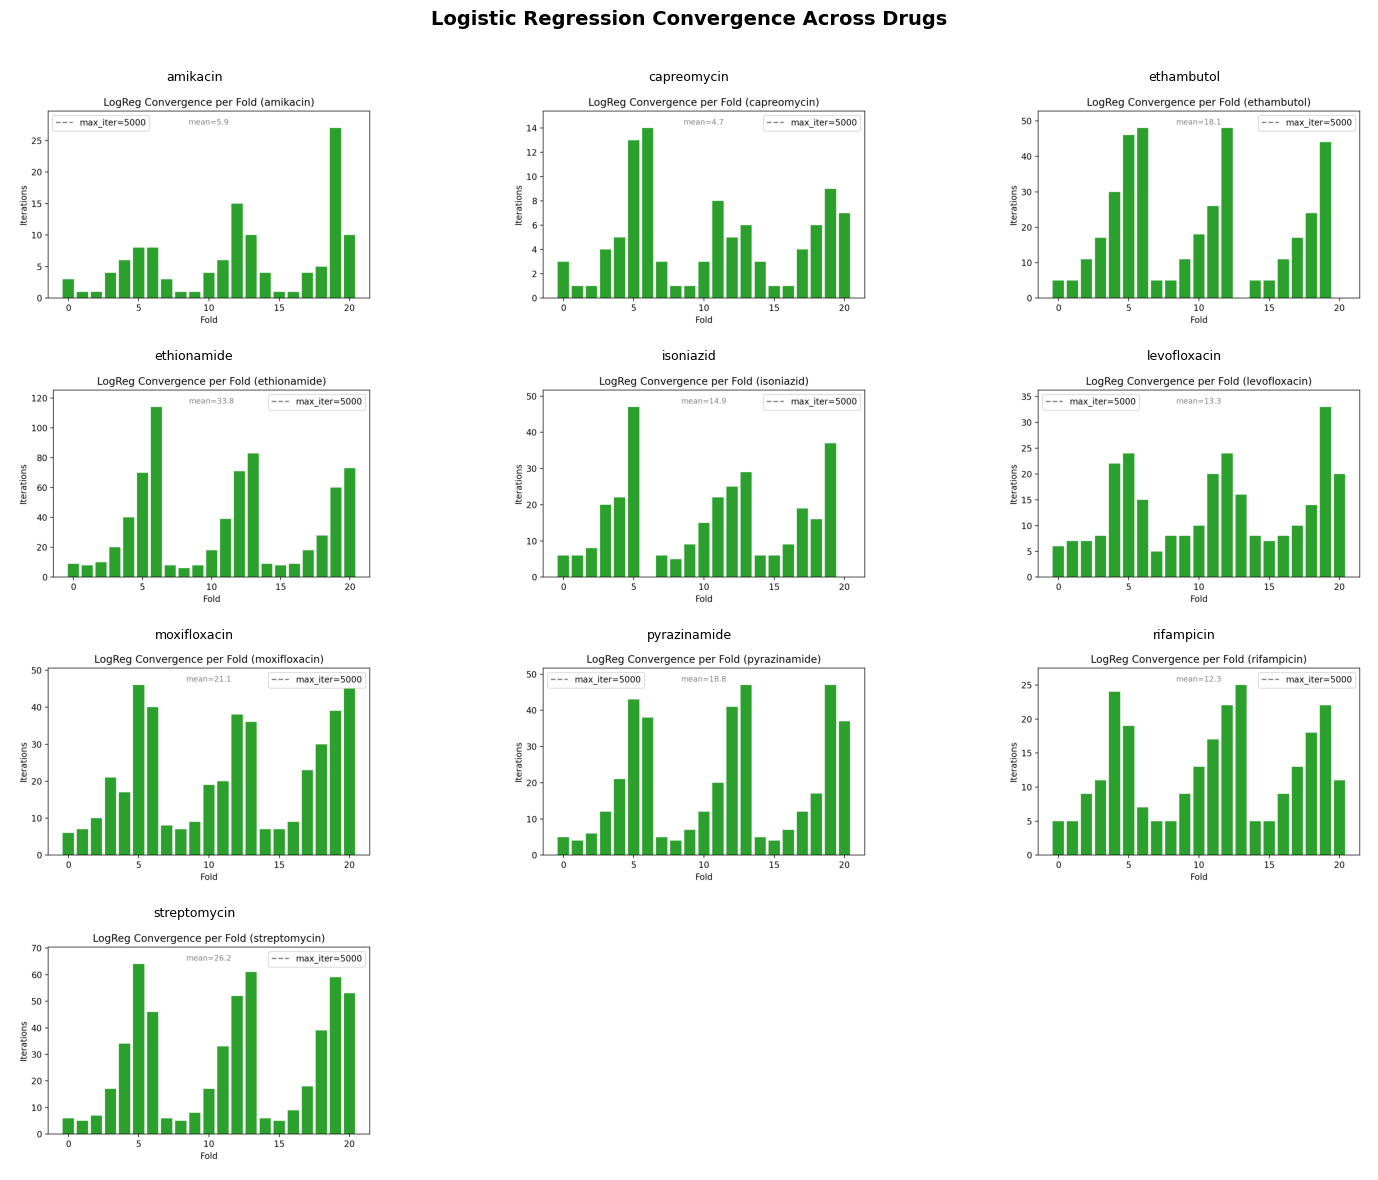

 Combined convergence grid saved to: ../data/latest/results/prediction/regression/convergence/logreg_convergence_grid.png


In [11]:
import os
import math
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------
BASE_DIR = Path("../data/latest/results/prediction/regression/convergence")
OUT_FIG  = BASE_DIR / "logreg_convergence_grid.png"

# collect all saved convergence figures
png_files = sorted(BASE_DIR.glob("*_convergence_zoomed.png"))
if not png_files:
    raise FileNotFoundError(f"No convergence plots found under {BASE_DIR}")

# auto grid layout
n = len(png_files)
cols = 3
rows = math.ceil(n / cols)

# load all images
images = [Image.open(p) for p in png_files]
w, h = images[0].size

# create figure
fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*3))
axes = axes.flatten()

for i, (ax, img_path) in enumerate(zip(axes, png_files)):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(img_path.stem.replace("_convergence_zoomed", ""), fontsize=9)
    ax.axis("off")

# remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Logistic Regression Convergence Across Drugs", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(OUT_FIG, dpi=250)
plt.show()
plt.close(fig)

print(f" Combined convergence grid saved to: {OUT_FIG}")


In [12]:
rows = []
for drug, model_dict in all_results.items():            # e.g. {'lasso':{'r2':…}}
    for model, metrics in model_dict.items():
        row = {"drug": drug, "model": model}
        row.update(metrics)                             # r2 / auc / mse
        rows.append(row)

results_df = pd.DataFrame(rows)
results_df
results_df.to_csv("../data/latest/results/prediction/regression_all_results_metrics.csv", index=False)
print("saved all_results_metrics.csv")

saved all_results_metrics.csv


In [13]:
pr_df = pd.concat(all_pr.values(), ignore_index=True)
pr_df
pr_df.to_csv("../data/latest/results/interpretability/regression/pr_tables/precision_recall_all_drugs_COMBINED.csv", index=False)
print("saved all_pr_rows.csv")

saved all_pr_rows.csv
